In [ ]:
#Diabetes dataset - AdaBoostClassifier and AdaBoostRegressor on the same dataset
#Regression vs Classification
#Regression - Predict the continuous disease progression score.
#Classification: Binarize the target (e.g., above median = 1, below = 0).

In [ ]:
#How AdaBoostClassifier handles binary targets and evaluates with accuracy/F1.
#How AdaBoostRegressor models continuous targets and evaluates with MSE/R².
#How feature importance differs between classification and regression.
#How predictions behave visually in regression.

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


🔹 Classification Results
Accuracy: 0.7443609022556391
              precision    recall  f1-score   support

           0       0.81      0.69      0.75        72
           1       0.69      0.80      0.74        61

    accuracy                           0.74       133
   macro avg       0.75      0.75      0.74       133
weighted avg       0.75      0.74      0.74       133


🔹 Regression Results
MSE: 3323.3233708746106
R² Score: 0.384376823726405


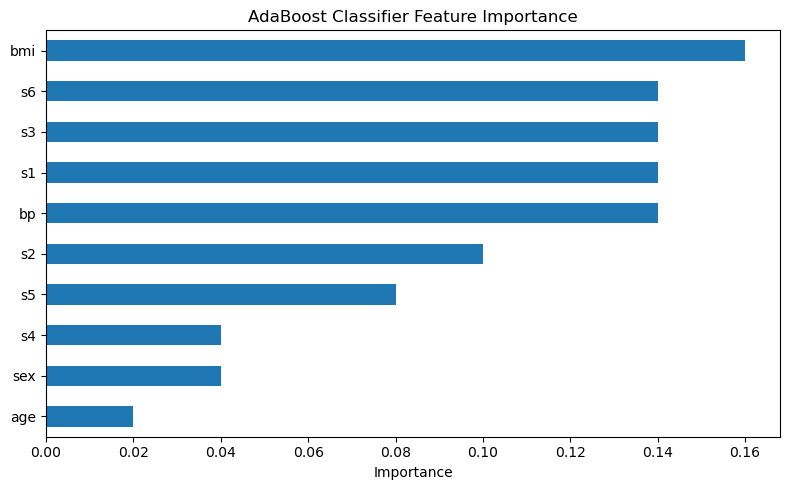

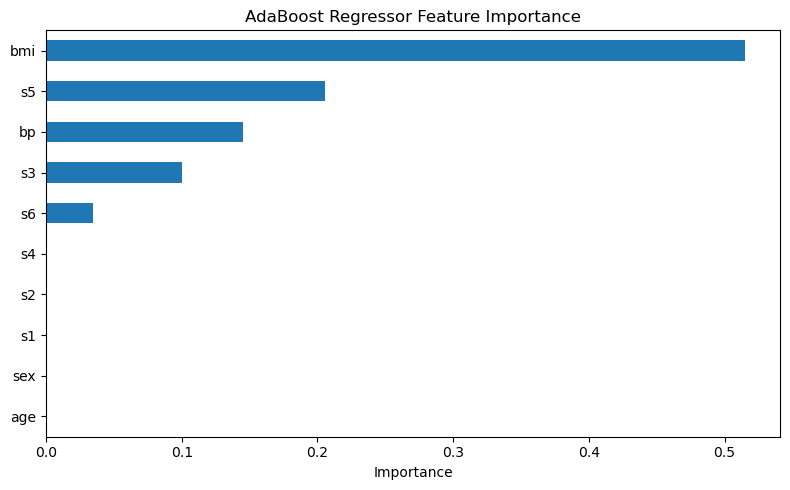

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    mean_squared_error, r2_score
)

# Load dataset
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y_reg = data.target

#x: features (refer features in dataset)
#y_reg=continuous target (disease progression metric) 

# Binarize target for classification
threshold = np.median(y_reg)
y_clf = (y_reg > threshold).astype(int)
#converts the regression target into binary classification
# 1 if disease progression > median
# 0 otherwise


# Train-test split
X_train, X_test, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.3, random_state=42)
_, _, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.3, random_state=42)

# AdaBoost Classifier
clf_model = AdaBoostClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
clf_model.fit(X_train, y_clf_train)
y_clf_pred = clf_model.predict(X_test)

# AdaBoost Regressor
reg_model = AdaBoostRegressor(
    base_estimator=DecisionTreeRegressor(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
reg_model.fit(X_train, y_reg_train)
y_reg_pred = reg_model.predict(X_test)

# Evaluation
print("🔹 Classification Results")
print("Accuracy:", accuracy_score(y_clf_test, y_clf_pred))
print(classification_report(y_clf_test, y_clf_pred))

print("\n🔹 Regression Results")
print("MSE:", mean_squared_error(y_reg_test, y_reg_pred))
print("R² Score:", r2_score(y_reg_test, y_reg_pred))

# Feature Importance Plot
def plot_feature_importance(model, title):
    importance = pd.Series(model.feature_importances_, index=X.columns)
    importance.sort_values().plot(kind='barh', figsize=(8,5), title=title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

plot_feature_importance(clf_model, "AdaBoost Classifier Feature Importance")
plot_feature_importance(reg_model, "AdaBoost Regressor Feature Importance")





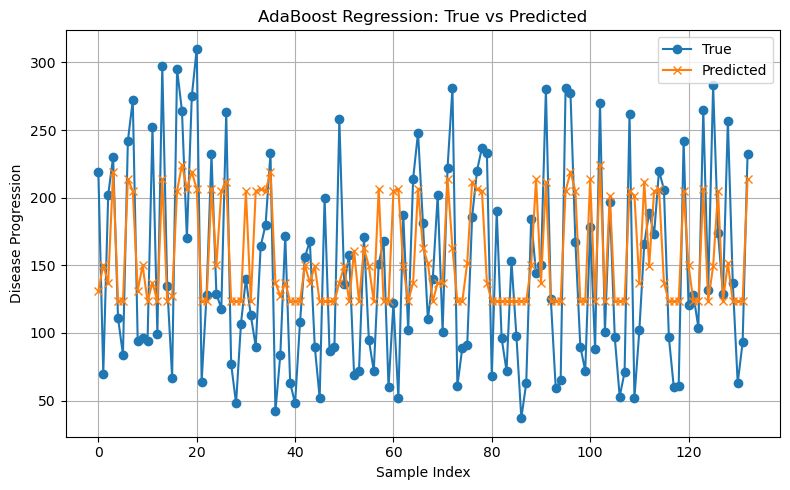

In [3]:
# Regression Prediction Curve
plt.figure(figsize=(8,5))
plt.plot(y_reg_test, label="True", marker='o')
plt.plot(y_reg_pred, label="Predicted", marker='x')
plt.title("AdaBoost Regression: True vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("Disease Progression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Regression Results
#MSE: 3323.3233708746106 - on average, predictions deviate from true values by  = ~57 units 
#R² Score: 0.384376823726405 - the model explains 38.4% of the variance in disease progression